In [1]:
# Importing the naccessry tools 
import pandas as pd 
import numpy as np
import plotly.express as px

# importing the ML tools 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
# Imporitng the advanced metrics tools 
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

print("Tools imported !!")

Tools imported !!


In [2]:
# 1. Simulate a dataset of 400 Students
rng = np.random.default_rng(seed=7)
study_hours  = rng.uniform(1, 10, size=400)
sleep_hours  = rng.uniform(4, 9, size=400)
distractions = rng.uniform(0, 5, size=400)

# Score formula, anyone above 70 Passes (1), otherwise Fails (0)
hidden_scores = 40 + (6.5 * study_hours) + (1.2 * sleep_hours) - (2.0 * distractions) + rng.normal(0, 7, size=400)
y = (hidden_scores >= 70).astype(int)
X = pd.DataFrame({'Study_Hours': study_hours, 'Sleep_Hours': sleep_hours, 'Distractions': distractions})

# Let's view our simulated students!
df_students = X.copy()
df_students['Pass_Fail'] = y
print("--- SIMULATED STUDENT DATA ---")
display(df_students.head())

# 2. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
print("\nData Split! Ready for training.")

--- SIMULATED STUDENT DATA ---


,Study_Hours,Sleep_Hours,Distractions,Pass_Fail
0,6.625859,5.647171,4.986138,1
1,9.074924,8.683216,0.783345,1
2,7.981171,4.775651,4.064277,1
3,3.026865,6.572332,2.055465,0
4,3.701497,4.457770,3.916538,0



Data Split! Ready for training.


In [17]:
model=DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(X_train,y_train)

print("Training Score : ",model.score(X_train,y_train)*100,"%")
print("Testing score : ",model.score(X_test,y_test)*100,"%")

Training Score :  95.3125 %
Testing score :  93.75 %


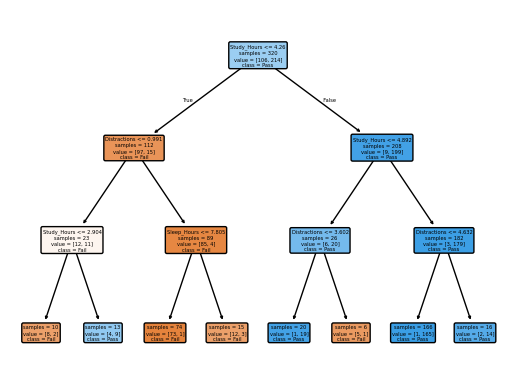

In [23]:
fig=plot_tree(model,
          feature_names=X.columns,
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          impurity=False,       # This hides the confusing Gini/Entropy math
          proportion=False)  


In [25]:
rf_model=RandomForestClassifier(n_estimators=100,max_depth=3,random_state=42)
rf_model.fit(X_train,y_train)

print("The training accuracy of model : ",rf_model.score(X_train,y_train)*100,"%")
print("The testing accuracy of model : ",rf_model.score(X_test,y_test)*100,"%")

The training accuracy of model :  95.0 %
The testing accuracy of model :  97.5 %


In [32]:
feature_importance=pd.DataFrame({
    "Feature":X.columns,
    "Feature_Value":rf_model.feature_importances_*100

}).sort_values(by="Feature_Value",ascending=False)

fig=px.bar(
    feature_importance,
    x="Feature",
    y="Feature_Value",
    title="features importance"

)
fig.show()